In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
films_raw = pd.read_csv('data/film_statistics.csv')
films_df = films_raw[[
    'movie_title', 'production_date', 'genres', 'runtime_minutes',
    'director_name', 'movie_averageRating', 'Production budget $'
]].copy()

films_df.columns = ['title', 'year', 'genres', 'duration', 'creator', 'rating', 'budget']
films_df['media_type'] = 'film'

films_df['year'] = pd.to_datetime(films_df['year'], errors='coerce').dt.year

films_df['duration'] = pd.to_numeric(films_df['duration'], errors='coerce')
films_df['rating']   = pd.to_numeric(films_df['rating'], errors='coerce')
films_df['budget']   = pd.to_numeric(films_df['budget'], errors='coerce')

print(films_df.shape)
films_df.head()

(4380, 8)


,title,year,genres,duration,creator,rating,budget,media_type
0,Avatar: The Way of Water,2022,"Action,Adventure,Fantasy",192.0,James Cameron,7.8,460000000,film
1,Avengers: Endgame,2019,"Action,Adventure,Drama",181.0,-,8.4,400000000,film
2,Pirates of the Caribbean: On Stranger Tides,2011,"Action,Adventure,Fantasy",137.0,Rob Marshall,6.6,379000000,film
3,Avengers: Age of Ultron,2015,"Action,Adventure,Sci-Fi",141.0,Joss Whedon,7.3,365000000,film
4,Avengers: Infinity War,2018,"Action,Adventure,Sci-Fi",149.0,-,8.4,300000000,film


In [3]:
anime_raw = pd.read_csv('data/animes.csv')

anime_df = anime_raw[['title', 'genre', 'aired', 'episodes', 'score', 'synopsis']].copy()
anime_df.columns = ['title', 'genres', 'year', 'episodes', 'rating', 'synopsis']
anime_df['media_type'] = 'anime'
anime_df['budget'] = np.nan
anime_df['creator'] = np.nan
anime_df['duration'] = np.nan

anime_df['year'] = anime_df['year'].str.extract(r'(\d{4})').astype(float)

anime_df['rating'] = pd.to_numeric(anime_df['rating'], errors='coerce')

anime_df['episodes'] = pd.to_numeric(anime_df['episodes'], errors='coerce')

anime_df['synopsis'] = anime_df['synopsis'].fillna('').astype(str)

anime_df['synopsis_len'] = anime_df['synopsis'].apply(len)
anime_df['synopsis_word_count'] = anime_df['synopsis'].apply(lambda x: len(x.split()))

print('Аниме загружено и обработано:', anime_df.shape)
anime_df[['title', 'year', 'genres', 'episodes', 'rating', 'synopsis_len', 'synopsis_word_count']].head(3)

Аниме загружено и обработано: (19311, 12)


,title,year,genres,episodes,rating,synopsis_len,synopsis_word_count
0,Haikyuu!! Second Season,2015.0,"['Comedy', 'Sports', 'Drama', 'School', 'Shoun...",25.0,8.82,1041,161
1,Shigatsu wa Kimi no Uso,2014.0,"['Drama', 'Music', 'Romance', 'School', 'Shoun...",22.0,8.83,838,141
2,Made in Abyss,2017.0,"['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'F...",13.0,8.83,1214,212


In [4]:
common_df = pd.concat([films_df, anime_df], ignore_index=True)
print('Общий размер:', common_df.shape)
common_df.to_csv('data/merged_dataset.csv', index=False)
common_df.head()

Общий размер: (23691, 12)


,title,year,genres,duration,creator,rating,budget,media_type,episodes,synopsis,synopsis_len,synopsis_word_count
0,Avatar: The Way of Water,2022.0,"Action,Adventure,Fantasy",192.0,James Cameron,7.8,460000000.0,film,NaN,NaN,NaN,NaN
1,Avengers: Endgame,2019.0,"Action,Adventure,Drama",181.0,-,8.4,400000000.0,film,NaN,NaN,NaN,NaN
2,Pirates of the Caribbean: On Stranger Tides,2011.0,"Action,Adventure,Fantasy",137.0,Rob Marshall,6.6,379000000.0,film,NaN,NaN,NaN,NaN
3,Avengers: Age of Ultron,2015.0,"Action,Adventure,Sci-Fi",141.0,Joss Whedon,7.3,365000000.0,film,NaN,NaN,NaN,NaN
4,Avengers: Infinity War,2018.0,"Action,Adventure,Sci-Fi",149.0,-,8.4,300000000.0,film,NaN,NaN,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 23691 entries, 0 to 23690
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                23691 non-null  str    
 1   year                 23319 non-null  float64
 2   genres               23691 non-null  str    
 3   duration             4380 non-null   float64
 4   creator              4380 non-null   object 
 5   rating               23112 non-null  float64
 6   budget               4380 non-null   float64
 7   media_type           23691 non-null  str    
 8   episodes             18605 non-null  float64
 9   synopsis             19311 non-null  str    
 10  synopsis_len         19311 non-null  float64
 11  synopsis_word_count  19311 non-null  float64
dtypes: float64(7), object(1), str(4)
memory usage: 2.2+ MB

Пропущенных значений:
title                      0
year                     372
genres                     0
duration               19311
cre

/var/folders/_c/bmb0qj8x3g99mm2mrn63f4sw0000gn/T/ipykernel_17334/3819576233.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1200x600 with 0 Axes>

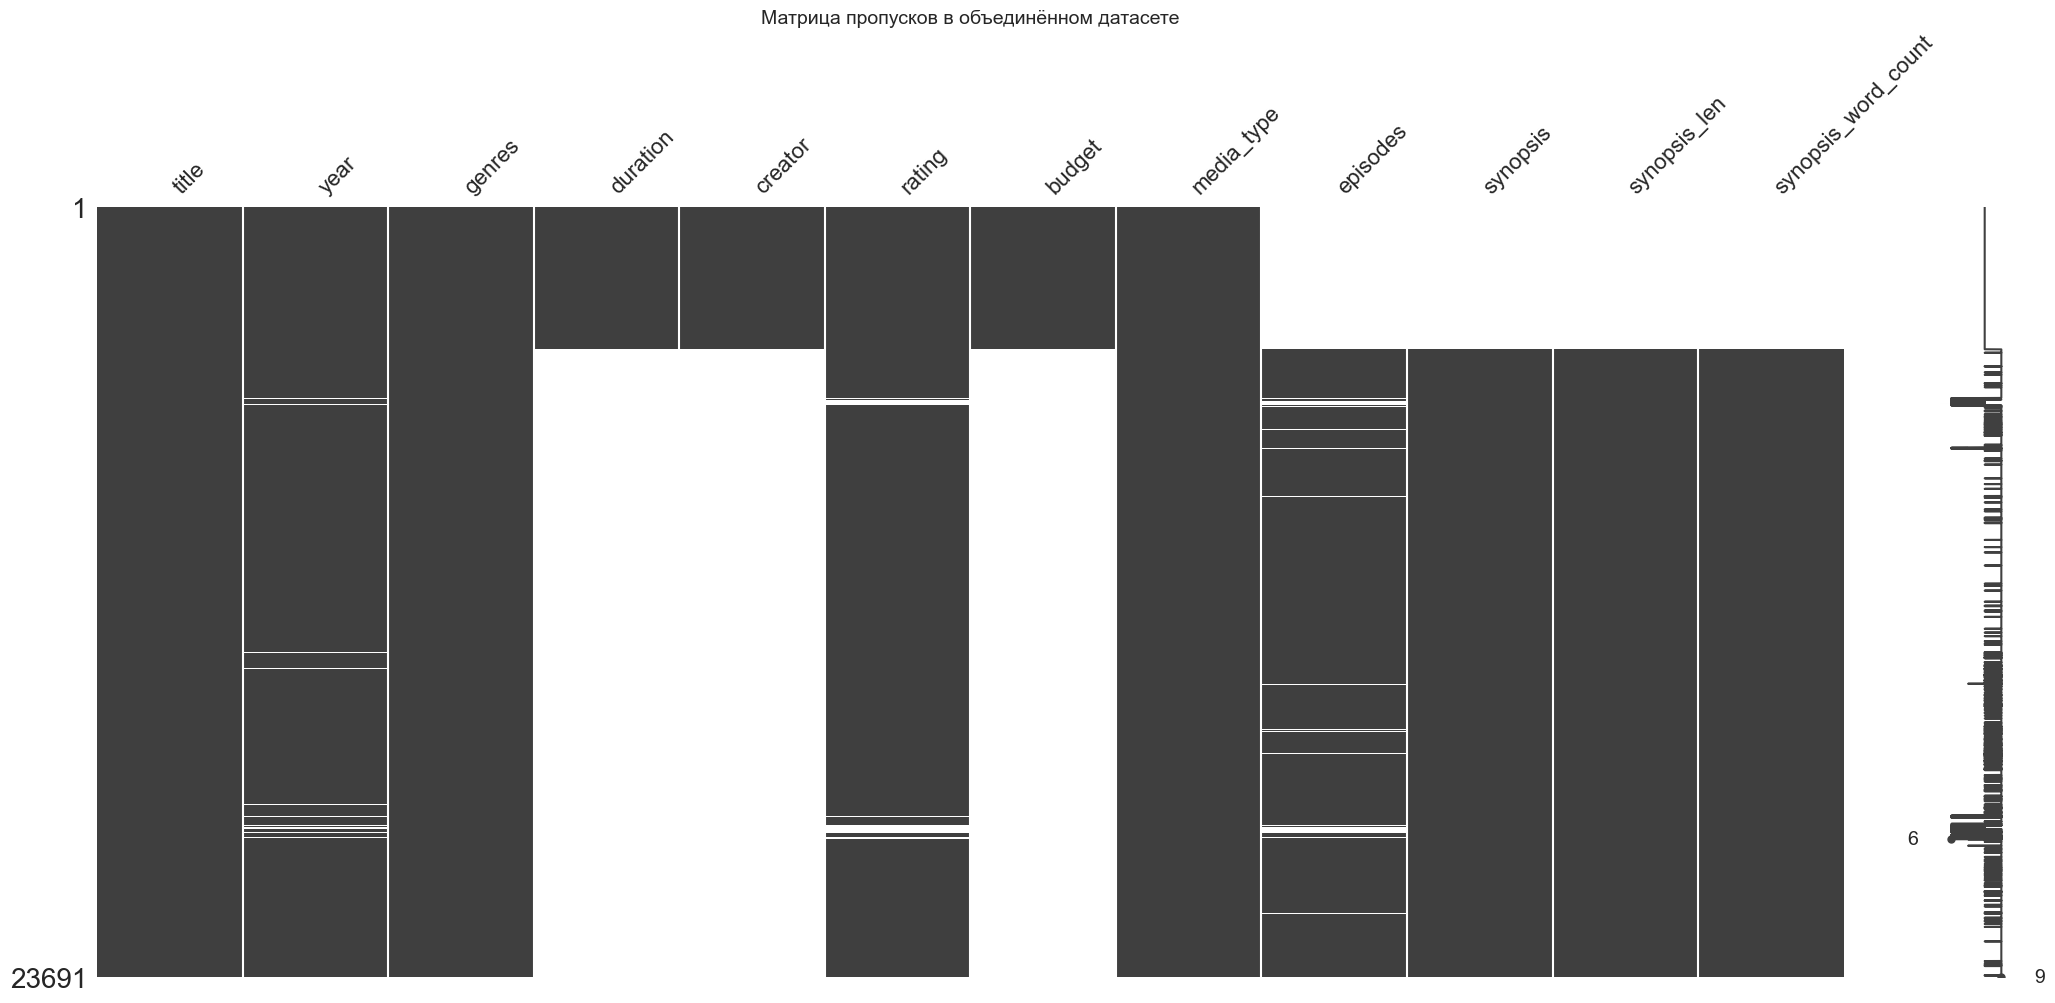

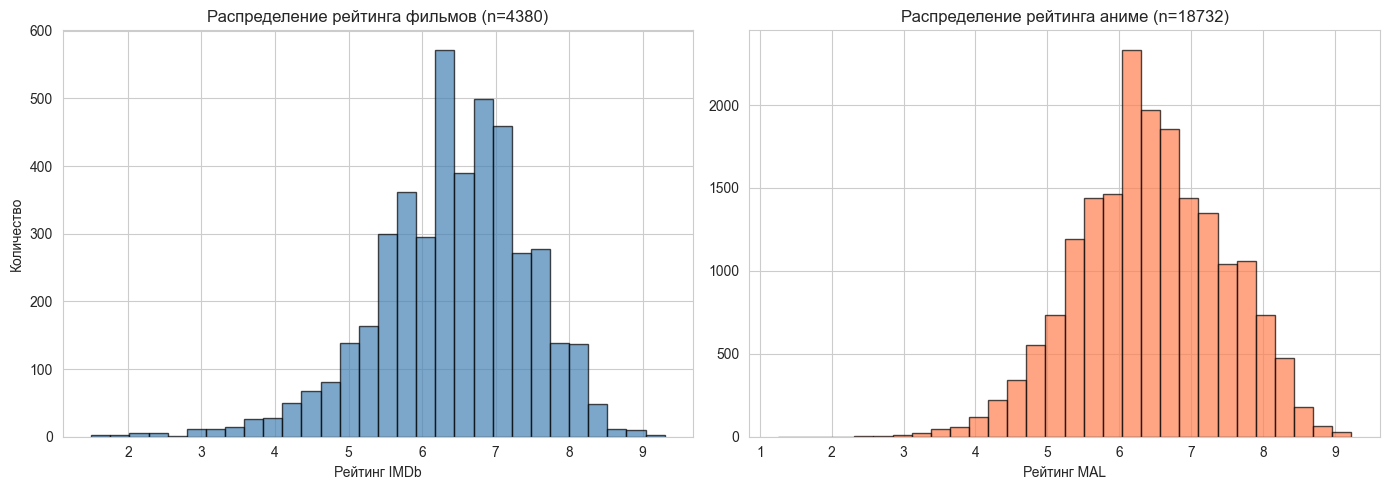

/var/folders/_c/bmb0qj8x3g99mm2mrn63f4sw0000gn/T/ipykernel_17334/3819576233.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,2].boxplot([film_dur.values, anime_ep.values], labels=['Фильмы (мин)', 'Аниме (эпизоды)'])


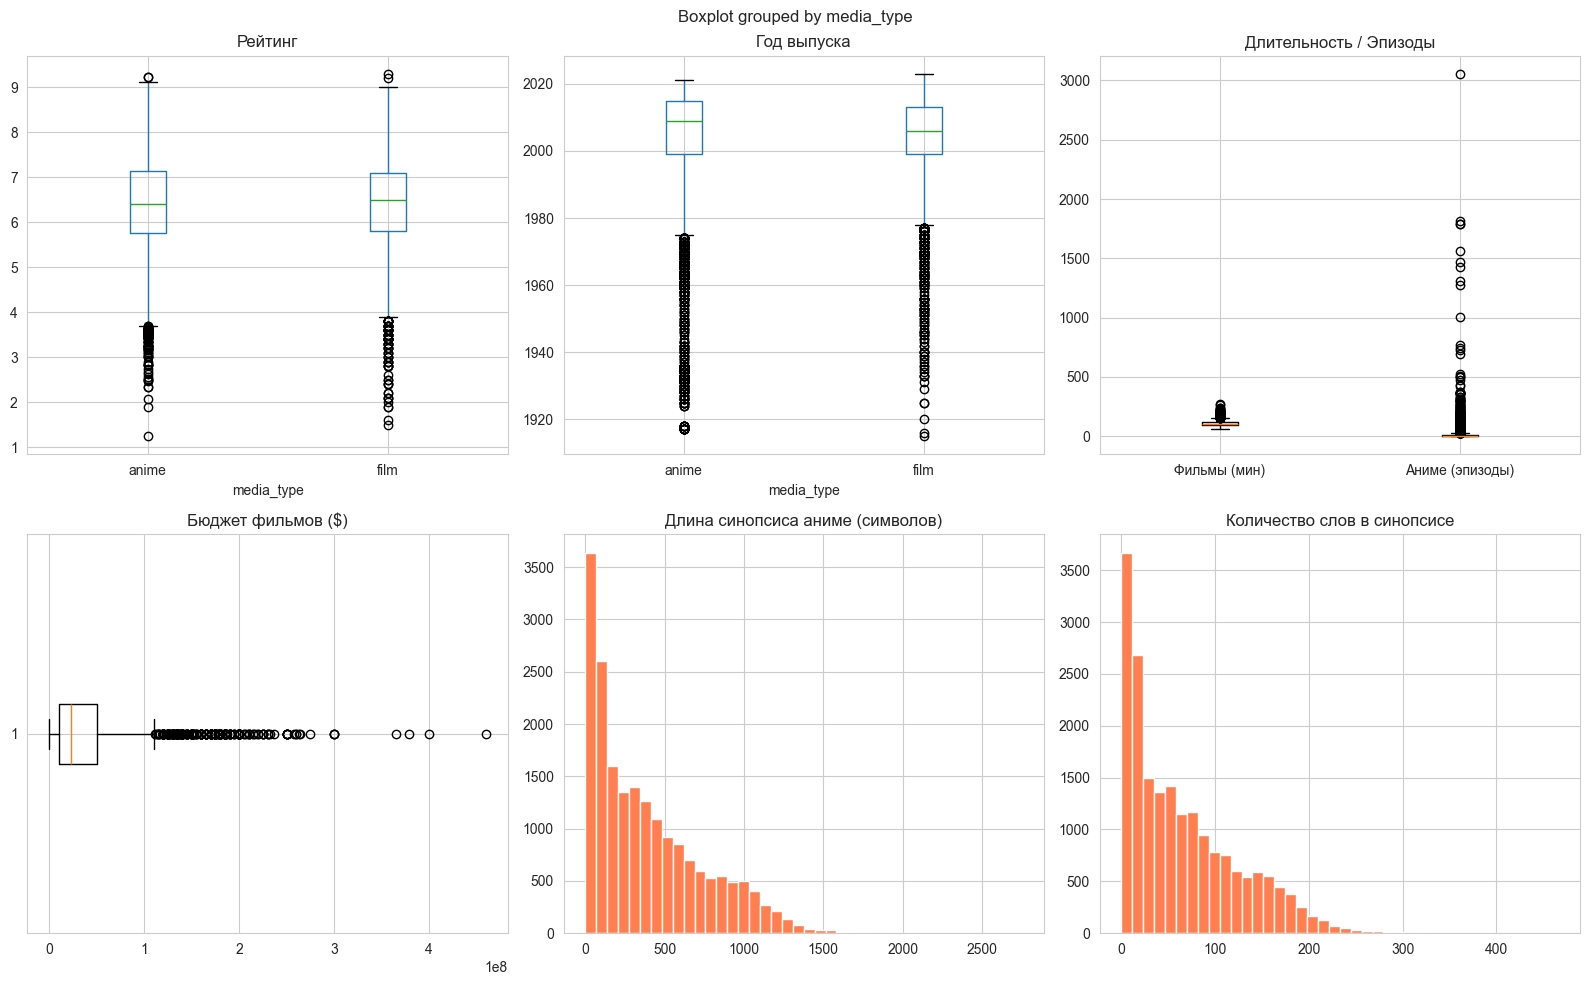

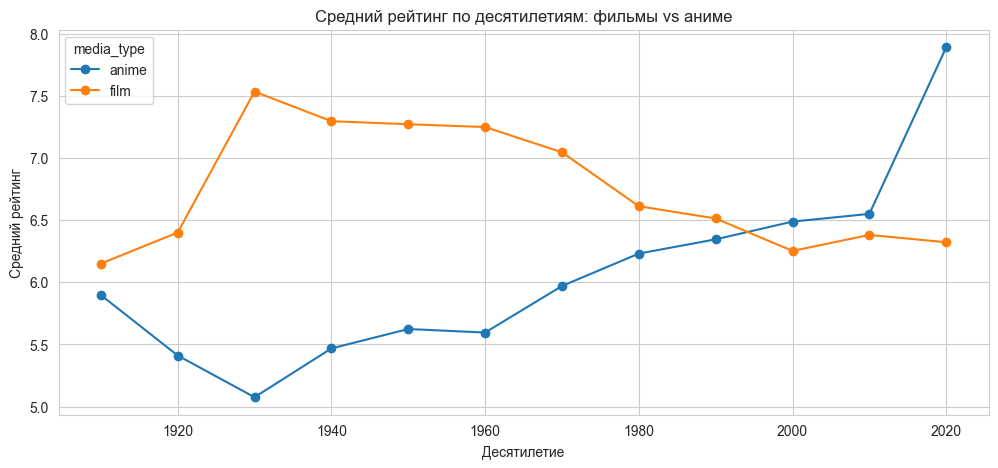

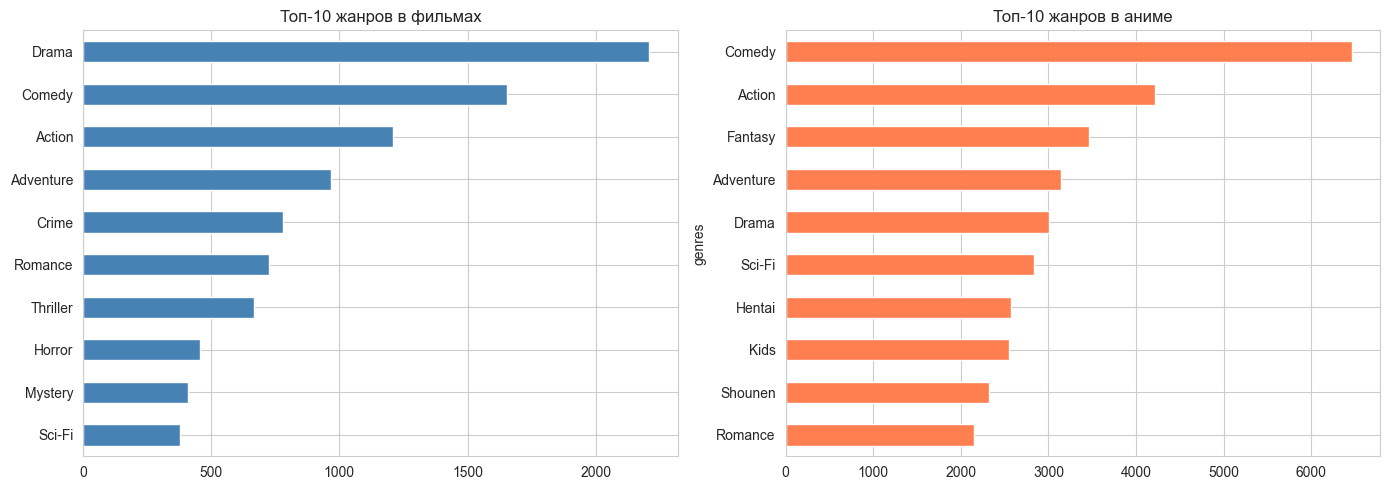

In [5]:
common_df.info()
print("\nПропущенных значений:")
print(common_df.isnull().sum())

plt.figure(figsize=(12,6))
msno.matrix(common_df)
plt.title('Матрица пропусков в объединённом датасете', fontsize=14)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14,5))
# Фильмы
film_ratings = common_df[common_df['media_type'] == 'film']['rating'].dropna()
axes[0].hist(film_ratings, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Распределение рейтинга фильмов (n={len(film_ratings)})', fontsize=12)
axes[0].set_xlabel('Рейтинг IMDb')
axes[0].set_ylabel('Количество')
# Аниме
anime_ratings = common_df[common_df['media_type'] == 'anime']['rating'].dropna()
axes[1].hist(anime_ratings, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Распределение рейтинга аниме (n={len(anime_ratings)})', fontsize=12)
axes[1].set_xlabel('Рейтинг MAL')
plt.tight_layout()
plt.show()

# Числовые признаки:
fig, axes = plt.subplots(2, 3, figsize=(16,10))
# Рейтинг
common_df.boxplot(column='rating', by='media_type', ax=axes[0,0])
axes[0,0].set_title('Рейтинг')
# Год
common_df.boxplot(column='year', by='media_type', ax=axes[0,1])
axes[0,1].set_title('Год выпуска')
# Длительность / эпизоды
# Для фильмов duration, для аниме episodes
film_dur = common_df[common_df['media_type']=='film']['duration'].dropna()
anime_ep = common_df[common_df['media_type']=='anime']['episodes'].dropna()
axes[0,2].boxplot([film_dur.values, anime_ep.values], labels=['Фильмы (мин)', 'Аниме (эпизоды)'])
axes[0,2].set_title('Длительность / Эпизоды')

# Бюджет (только фильмы)
film_budget = common_df[common_df['media_type']=='film']['budget'].dropna()
axes[1,0].boxplot(film_budget, vert=False)
axes[1,0].set_title('Бюджет фильмов ($)')

# Длина синопсиса (только аниме)
anime_syn_len = common_df[common_df['media_type']=='anime']['synopsis_len'].dropna()
axes[1,1].hist(anime_syn_len, bins=40, color='coral')
axes[1,1].set_title('Длина синопсиса аниме (символов)')

# Количество слов в синопсисе
anime_syn_wc = common_df[common_df['media_type']=='anime']['synopsis_word_count'].dropna()
axes[1,2].hist(anime_syn_wc, bins=40, color='coral')
axes[1,2].set_title('Количество слов в синопсисе')
plt.tight_layout()
plt.show()

common_df['decade'] = (common_df['year'] // 10 * 10).astype('Int64')  # Int64 чтобы сохранить NaN
decade_rating = common_df.groupby(['decade', 'media_type'])['rating'].mean().unstack()
decade_rating.plot(marker='o', figsize=(12,5))
plt.title('Средний рейтинг по десятилетиям: фильмы vs аниме')
plt.xlabel('Десятилетие')
plt.ylabel('Средний рейтинг')
plt.grid(True)
plt.legend(title='media_type')
plt.show()

film_genres_series = common_df[common_df['media_type']=='film']['genres'].dropna().str.split(',', expand=True).stack().str.strip()
top_film_genres = film_genres_series.value_counts().head(10)

import ast
def extract_genres_anime(genre_str):
    try:
        return ast.literal_eval(genre_str)
    except:
        return []
anime_genre_lists = common_df[common_df['media_type']=='anime']['genres'].dropna().apply(extract_genres_anime)
anime_genres_exploded = anime_genre_lists.explode().str.strip()
top_anime_genres = anime_genres_exploded.value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14,5))
top_film_genres.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Топ-10 жанров в фильмах')
axes[0].invert_yaxis()
top_anime_genres.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Топ-10 жанров в аниме')
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

In [6]:
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
import ast

df = common_df.copy()

df['creator'] = df['creator'].replace('-', np.nan)
df['decade'] = (df['year'] // 10 * 10).astype('Int64')
df['is_modern'] = (df['year'] >= 2000).astype(int)

df['total_runtime'] = np.where(df['media_type'] == 'film', df['duration'], df['episodes'] * 24)

df['log_budget'] = np.log1p(df['budget'])

df['synopsis_len'] = df['synopsis_len'].fillna(0)
df['synopsis_word_count'] = df['synopsis_word_count'].fillna(0)

df['is_anime'] = (df['media_type'] == 'anime').astype(int)

def parse_genres(row):
    if pd.isna(row['genres']):
        return []
    if row['media_type'] == 'film':
        return [g.strip() for g in row['genres'].split(',')]
    try:
        return ast.literal_eval(row['genres'])
    except:
        return []

df['genre_list'] = df.apply(parse_genres, axis=1)

mlb = MultiLabelBinarizer()
genre_encoded = mlb.fit_transform(df['genre_list'])
genre_df = pd.DataFrame(genre_encoded, columns=mlb.classes_, index=df.index)

top_genres = genre_df.sum().sort_values(ascending=False).head(20).index.tolist()
df = pd.concat([df, genre_df[top_genres]], axis=1)

df['rating_norm'] = df.groupby('media_type')['rating'].transform(lambda x: (x - x.mean()) / x.std())

df = df.dropna(subset=['rating', 'rating_norm']).copy()

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

director_stats = df_train[df_train['media_type'] == 'film'].groupby('creator').agg(
    director_mean_rating=('rating', 'mean'),
    director_films_count=('rating', 'count')
).reset_index()

df_train = df_train.merge(director_stats, on='creator', how='left')
df_test = df_test.merge(director_stats, on='creator', how='left')

train_dir_mean = df_train['director_mean_rating'].median()

for dataset in [df_train, df_test]:
    dataset['director_mean_rating'] = dataset['director_mean_rating'].fillna(train_dir_mean)
    dataset['director_films_count'] = dataset['director_films_count'].fillna(0)
    dataset['is_prolific_director'] = (dataset['director_films_count'] >= 3).astype(int)

impute_cols = ['log_budget', 'total_runtime', 'year']

def impute_by_group(train, test, cols, group_col):
    for c in cols:
        medians = train.groupby(group_col)[c].median()
        overall_median = train[c].median()
        
        def get_val(r):
            if pd.isna(r[c]):
                val = medians.get(r[group_col])
                if pd.isna(val):
                    return 0.0 if c == 'log_budget' else overall_median
                return val
            return r[c]
            
        train[c] = train.apply(get_val, axis=1)
        test[c]  = test.apply(get_val, axis=1)
    return train, test

df_train, df_test = impute_by_group(df_train, df_test, impute_cols, 'media_type')

feature_cols = [
    'year', 'total_runtime', 'synopsis_len', 'synopsis_word_count',
    'log_budget', 'is_modern', 'is_anime',
    'director_mean_rating', 'director_films_count', 'is_prolific_director'
] + top_genres

# Фильмы
mask_train_film = df_train['media_type'] == 'film'
mask_test_film  = df_test['media_type'] == 'film'
X_film_train, y_film_train = df_train[mask_train_film][feature_cols], df_train[mask_train_film]['rating']
X_film_test, y_film_test   = df_test[mask_test_film][feature_cols], df_test[mask_test_film]['rating']

# Аниме
mask_train_anime = df_train['media_type'] == 'anime'
mask_test_anime  = df_test['media_type'] == 'anime'
X_anime_train, y_anime_train = df_train[mask_train_anime][feature_cols], df_train[mask_train_anime]['rating']
X_anime_test, y_anime_test   = df_test[mask_test_anime][feature_cols], df_test[mask_test_anime]['rating']

# Общая 
X_all_train, y_all_train = df_train[feature_cols], df_train['rating_norm']
X_all_test, y_all_test   = df_test[feature_cols], df_test['rating_norm']

print("Утечка данных устранена, бюджет и тайминг объединены, таргеты нормализованы!")
print(f"Фильмы: Train {X_film_train.shape}, Test {X_film_test.shape}")
print(f"Аниме:  Train {X_anime_train.shape}, Test {X_anime_test.shape}")
print(f"Общая:  Train {X_all_train.shape}, Test {X_all_test.shape}")

Утечка данных устранена, бюджет и тайминг объединены, таргеты нормализованы!
Фильмы: Train (3503, 30), Test (877, 30)
Аниме:  Train (14986, 30), Test (3746, 30)
Общая:  Train (18489, 30), Test (4623, 30)


БАЗОВАЯ МОДЕЛЬ: Линейная регрессия
Фильмы: MAE=0.712, RMSE=0.944, R²=0.151
Аниме: MAE=0.626, RMSE=0.803, R²=0.374
Общая (нормализованная): MAE=0.652, RMSE=0.841, R²=0.301
СЛУЧАЙНЫЙ ЛЕС
Фильмы: MAE=0.700, RMSE=0.922, R²=0.189
Аниме: MAE=0.507, RMSE=0.688, R²=0.542
Общая (нормализованная): MAE=0.551, RMSE=0.741, R²=0.458
ГРАДИЕНТНЫЙ БУСТИНГ
Фильмы: MAE=0.680, RMSE=0.903, R²=0.222
Аниме: MAE=0.545, RMSE=0.719, R²=0.499
Общая (нормализованная): MAE=0.573, RMSE=0.756, R²=0.435
ТАБЛИЦА РЕЗУЛЬТАТОВ
                       Модель      MAE     RMSE       R²
               Ridge (фильмы) 0.712255 0.943608 0.151089
                Ridge (аниме) 0.625537 0.803260 0.374353
           Ridge (общая-норм) 0.651614 0.841120 0.301184
        RandomForest (фильмы) 0.700264 0.922191 0.189186
         RandomForest (аниме) 0.506694 0.687538 0.541636
    RandomForest (общая-норм) 0.550844 0.740679 0.458115
    GradientBoosting (фильмы) 0.680412 0.903441 0.221823
     GradientBoosting (аниме) 0.545079 0.718633

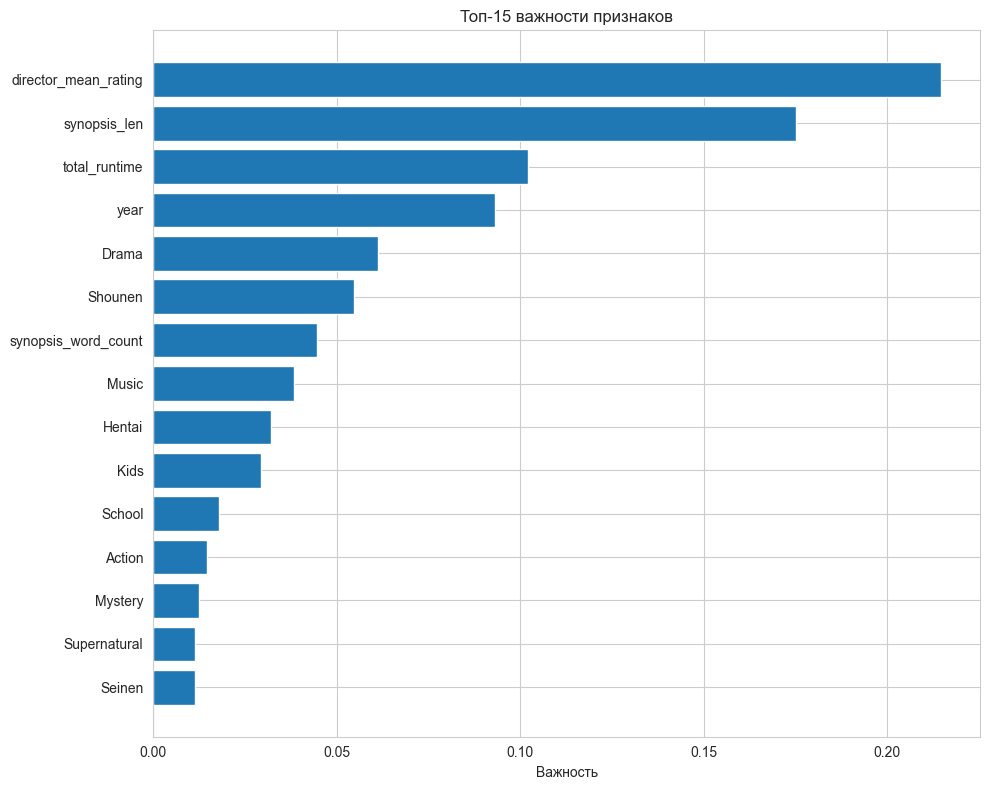

In [7]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

def evaluate_model(model, X_train, X_test, y_train, y_test, name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name}: MAE={mae:.3f}, RMSE={rmse:.3f}, R²={r2:.3f}")
    return model, {'MAE': mae, 'RMSE': rmse, 'R²': r2}

print("БАЗОВАЯ МОДЕЛЬ: Линейная регрессия")
ridge_film, ridge_film_metrics = evaluate_model(Ridge(alpha=1.0), X_film_train, X_film_test, y_film_train, y_film_test, "Фильмы")
ridge_anime, ridge_anime_metrics = evaluate_model(Ridge(alpha=1.0), X_anime_train, X_anime_test, y_anime_train, y_anime_test, "Аниме")
ridge_all, ridge_all_metrics = evaluate_model(Ridge(alpha=1.0), X_all_train, X_all_test, y_all_train, y_all_test, "Общая (нормализованная)")

print("СЛУЧАЙНЫЙ ЛЕС")
rf_film, rf_film_metrics = evaluate_model(RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1), X_film_train, X_film_test, y_film_train, y_film_test, "Фильмы")
rf_anime, rf_anime_metrics = evaluate_model(RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1), X_anime_train, X_anime_test, y_anime_train, y_anime_test, "Аниме")
rf_all, rf_all_metrics = evaluate_model(RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1), X_all_train, X_all_test, y_all_train, y_all_test, "Общая (нормализованная)")

print("ГРАДИЕНТНЫЙ БУСТИНГ")
gb_film, gb_film_metrics = evaluate_model(GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42), X_film_train, X_film_test, y_film_train, y_film_test, "Фильмы")
gb_anime, gb_anime_metrics = evaluate_model(GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42), X_anime_train, X_anime_test, y_anime_train, y_anime_test, "Аниме")
gb_all, gb_all_metrics = evaluate_model(GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42), X_all_train, X_all_test, y_all_train, y_all_test, "Общая (нормализованная)")

results_df = pd.DataFrame({
    'Модель': ['Ridge (фильмы)', 'Ridge (аниме)', 'Ridge (общая-норм)',
               'RandomForest (фильмы)', 'RandomForest (аниме)', 'RandomForest (общая-норм)',
               'GradientBoosting (фильмы)', 'GradientBoosting (аниме)', 'GradientBoosting (общая-норм)'],
    'MAE': [ridge_film_metrics['MAE'], ridge_anime_metrics['MAE'], ridge_all_metrics['MAE'],
            rf_film_metrics['MAE'], rf_anime_metrics['MAE'], rf_all_metrics['MAE'],
            gb_film_metrics['MAE'], gb_anime_metrics['MAE'], gb_all_metrics['MAE']],
    'RMSE': [ridge_film_metrics['RMSE'], ridge_anime_metrics['RMSE'], ridge_all_metrics['RMSE'],
             rf_film_metrics['RMSE'], rf_anime_metrics['RMSE'], rf_all_metrics['RMSE'],
             gb_film_metrics['RMSE'], gb_anime_metrics['RMSE'], gb_all_metrics['RMSE']],
    'R²': [ridge_film_metrics['R²'], ridge_anime_metrics['R²'], ridge_all_metrics['R²'],
           rf_film_metrics['R²'], rf_anime_metrics['R²'], rf_all_metrics['R²'],
           gb_film_metrics['R²'], gb_anime_metrics['R²'], gb_all_metrics['R²']]
})

print("ТАБЛИЦА РЕЗУЛЬТАТОВ")
print(results_df.to_string(index=False))

best_model = gb_all
X_train_best = X_all_train
X_test_best = X_all_test

print("РОЛЬ ПРИЗНАКОВ")

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.gca().invert_yaxis()
plt.title('Топ-15 важности признаков')
plt.xlabel('Важность')
plt.tight_layout()
plt.show()

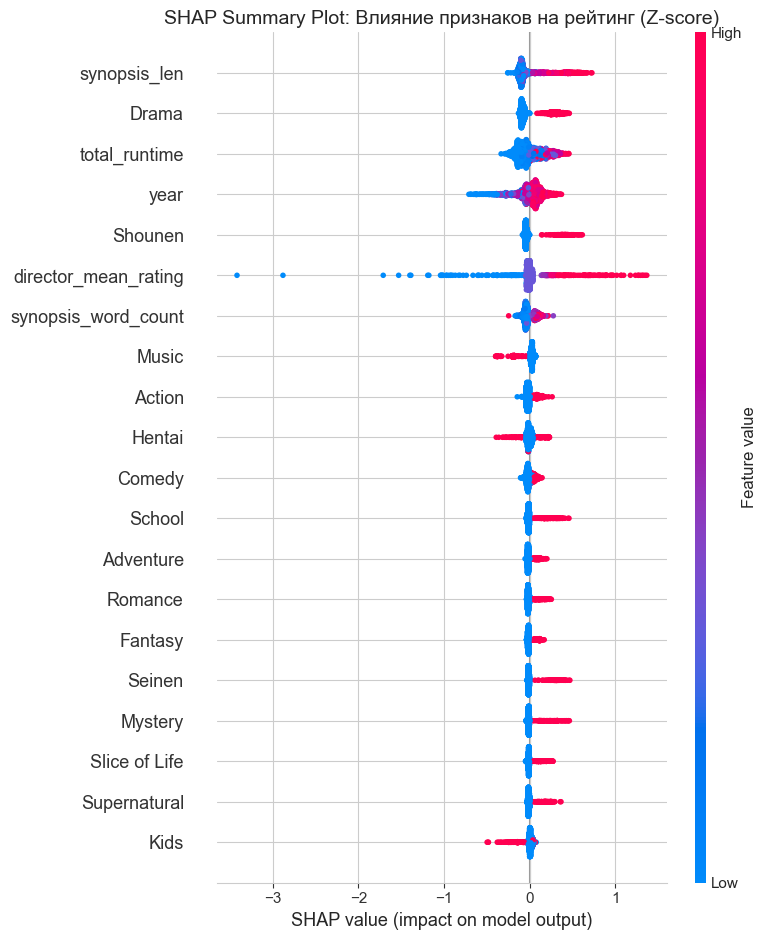

<Figure size 1000x600 with 0 Axes>

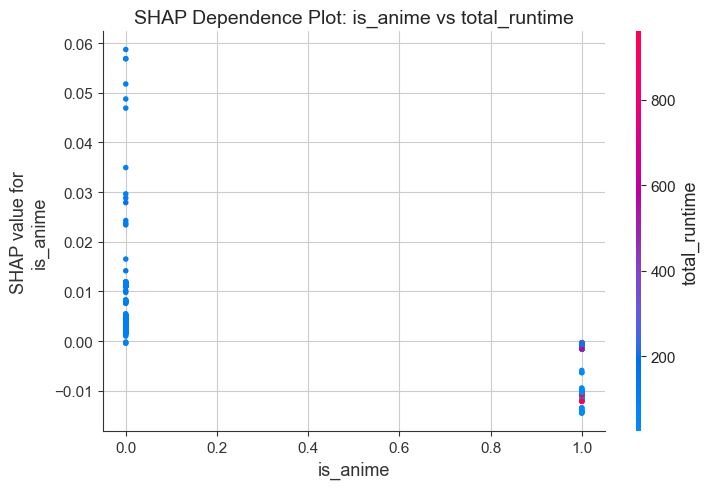

<Figure size 640x480 with 0 Axes>

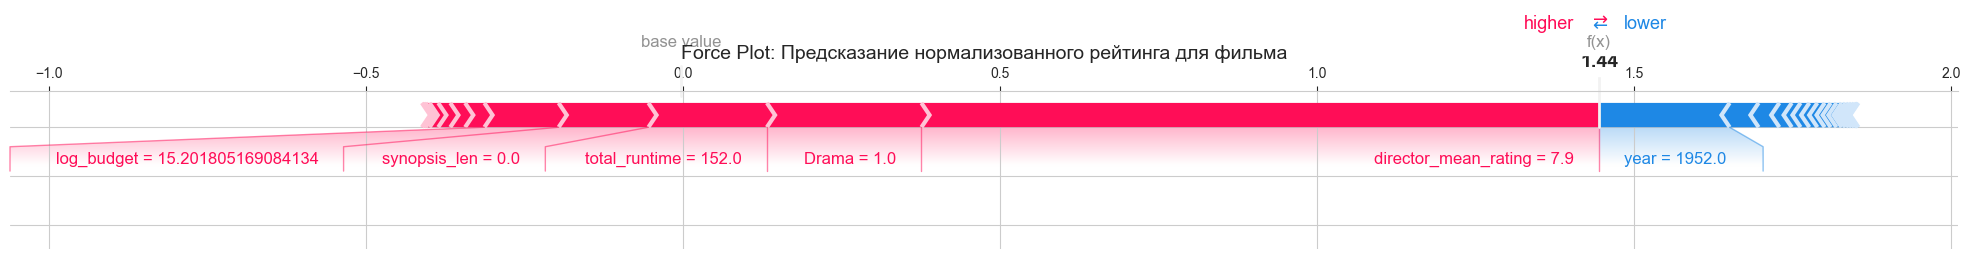

<Figure size 640x480 with 0 Axes>

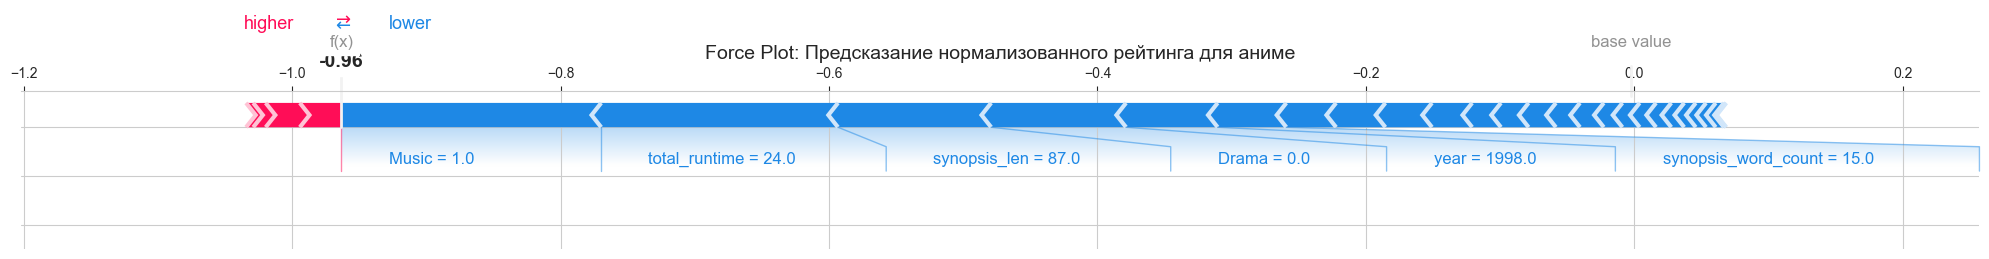

Анализ завершён


In [8]:
import shap

explainer = shap.TreeExplainer(best_model)

X_sample = X_test_best.sample(n=min(2000, len(X_test_best)), random_state=42)
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, feature_names=feature_cols, show=False)
plt.title('SHAP Summary Plot: Влияние признаков на рейтинг (Z-score)', fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.dependence_plot('is_anime', shap_values, X_sample, feature_names=feature_cols, 
                     interaction_index='total_runtime', show=False)
plt.title('SHAP Dependence Plot: is_anime vs total_runtime', fontsize=14)
plt.tight_layout()
plt.show()

film_sample_idx = X_sample[X_sample['is_anime'] == 0].index[0]
shap.initjs()
plt.figure()
shap.force_plot(explainer.expected_value, shap_values[X_sample.index.get_loc(film_sample_idx), :], 
                X_sample.iloc[X_sample.index.get_loc(film_sample_idx)], 
                feature_names=feature_cols, matplotlib=True, show=False)
plt.title('Force Plot: Предсказание нормализованного рейтинга для фильма', fontsize=14)
plt.tight_layout()
plt.show()

anime_sample_idx = X_sample[X_sample['is_anime'] == 1].index[0]
plt.figure()
shap.force_plot(explainer.expected_value, shap_values[X_sample.index.get_loc(anime_sample_idx), :], 
                X_sample.iloc[X_sample.index.get_loc(anime_sample_idx)], 
                feature_names=feature_cols, matplotlib=True, show=False)
plt.title('Force Plot: Предсказание нормализованного рейтинга для аниме', fontsize=14)
plt.tight_layout()
plt.show()

print("Анализ завершён")